In [1]:
# Базовые библиотеки для генерации данных, анализа и обучения простых моделей.
import math
import random
from dataclasses import dataclass

# PyTorch: нейросетевые блоки и работа с данными
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

# Делаем графики и табличный вывод чуть удобнее для демонстрации в ноутбуке.
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

In [2]:
# Фиксируем seed, чтобы синтетический ряд и результаты были воспроизводимыми.
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(42)

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

Device: cuda


In [4]:
df = pd.read_csv('/content/S12-hw-dataset.csv')
df.head()

,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    4320 non-null   object 
 1   target  4320 non-null   float64
dtypes: float64(1), object(1)
memory usage: 67.6+ KB


In [6]:
df.describe()

,target
count,4320.000000
mean,135.605840
std,21.384633
min,69.100000
25%,120.537500
50%,135.835000
75%,150.625000
max,210.100000


In [7]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(by='date', ascending=True)
df.head()

,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62


In [8]:
print(f"Общее количество наблюдений: {len(df)}")

Общее количество наблюдений: 4320


In [9]:
min_date = df['date'].min()
max_date = df['date'].max()
print(f"Диапазон дат: с {min_date} по {max_date}")
print(f"Продолжительность: {max_date - min_date}")

Диапазон дат: с 2025-01-01 00:00:00 по 2025-06-29 23:00:00
Продолжительность: 179 days 23:00:00


In [10]:
print("\nПропуски по колонкам:")
print(df.isnull().sum())


Пропуски по колонкам:
date      0
target    0
dtype: int64


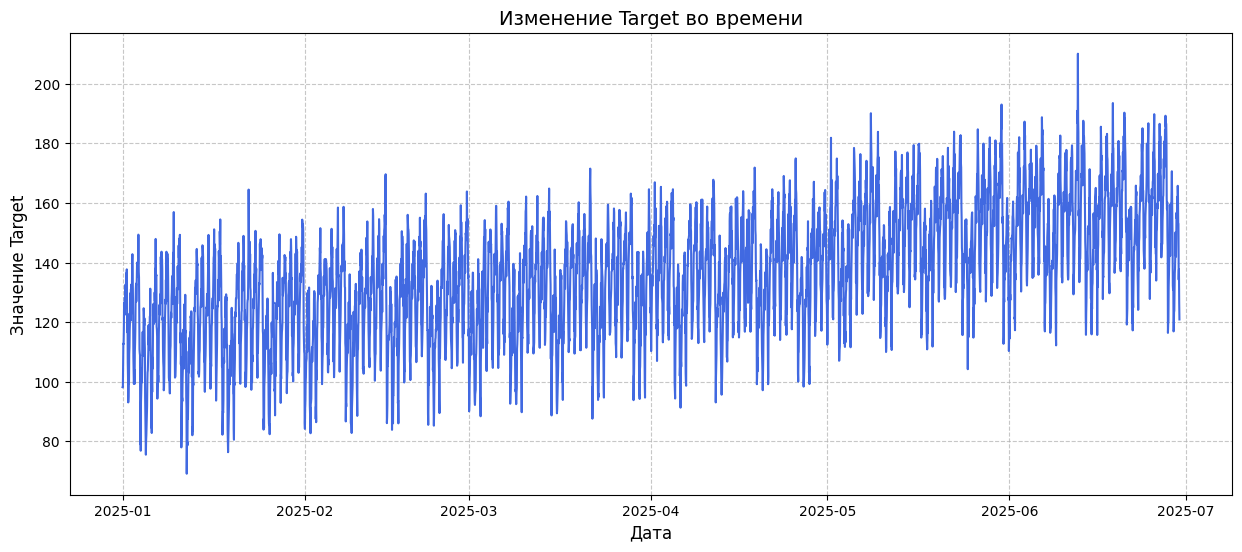

In [11]:
fig, ax = plt.subplots(figsize=(15,6))
ax.plot(df['date'], df['target'], color='royalblue', lw=1.5)
ax.set_title('Изменение Target во времени', fontsize=14)
ax.set_xlabel('Дата', fontsize=12)
ax.set_ylabel('Значение Target', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 📊 Анализ временного ряда (Target)

На основе визуального обследования представленного графика за период **январь – июнь 2025 года**, можно выделить следующие ключевые характеристики данных:

---

### 📈 1. Тренд (Trend)
* **Тип:** Выраженный **восходящий (линейный)** тренд.
* **Динамика:** Наблюдается постепенное смещение "базиса" ряда. Если в начале года (январь) значения колебались в диапазоне **80–140**, то к концу периода (июнь) нижняя граница поднялась до **120**, а верхняя — до **180+**.
* **Для моделей:** Линейный рост подтверждает необходимость использования признаков, учитывающих долгосрочную динамику (например, лаги большой глубины или порядковый номер дня).

### 🧬 2. Сезонность (Seasonality)
* **Характер:** Присутствует жесткая **циклическая сезонность** (структура «расчески»).
* **Визуальный признак:** Регулярные, высокочастотные пики и провалы с практически неизменной амплитудой на протяжении всего полугодия.
* **Для моделей:** Это идеальное условие для работы признаков `dow_sin`/`cos` (день недели) и `lag_7`. Модели будет легко выучить цикличный паттерн поведения.



### ⚡ 3. Выбросы (Outliers)
* **Общая картина:** Ряд характеризуется высокой плотностью и отсутствием критических аномалий.
* **Локальные всплески:** В июне заметен единичный "вылет" значения выше **210**.
* **Влияние:** Такие точечные выбросы могут незначительно завышать метрику **RMSE**, но не ломают общую логику обучения нейросети.

### 🌊 4. Нестационарность (Non-stationarity)
* **Вердикт:** Ряд является **нестационарным**.
* **Причины:** 1. **Непостоянство среднего:** Математическое ожидание растет вместе с трендом.
    2. **Возможная гетероскедастичность:** К маю-июню размах (дисперсия) между пиками и провалами визуально кажется чуть шире, чем в начале года.
* **Рекомендация:** Использование `StandardScaler` (Z-score нормализация) здесь оправдано, так как оно приводит разные уровни цен к единому масштабу для стабильного обучения GRU.

---
> **Вывод:** Данные обладают высокой предсказуемостью за счет стабильной сезонности и плавного тренда. Ожидается, что модели (Ridge и GRU) покажут высокую точность на данном ряде.

In [12]:
class SplitConfig:
  def __init__(self, train_frac=0.70, val_frac=0.15):
    self.train_frac = train_frac
    self.val_frac = val_frac

  def __repr__(self):
    return f'SplitConfig(train_frac={self.train_frac}, val_frac={self.val_frac})'

  def __eq__(self, other):
    if not isinstance(other, SplitConfig):
      return False
    return (self.train_frac == other.train_frac and self.val_frac == other.val_frac)

In [13]:
def temporal_split(df: pd.DataFrame, cfg: SplitConfig = SplitConfig()):
  n = len(df)
  train_end = int(n* cfg.train_frac)
  val_end = int(n* (cfg.train_frac + cfg.val_frac))

  train_df = df.iloc[:train_end].copy()
  val_df = df.iloc[train_end: val_end].copy()
  test_df = df.iloc[val_end:].copy()

  return train_df, val_df, test_df

train_df, val_df, test_df = temporal_split(df)

print(f"train: {train_df.shape}, {train_df['date'].min().date()} -> {train_df['date'].max().date()}")
print(f"val  : {val_df.shape}, {val_df['date'].min().date()} -> {val_df['date'].max().date()}")
print(f"test : {test_df.shape}, {test_df['date'].min().date()} -> {test_df['date'].max().date()}")

train: (3024, 2), 2025-01-01 -> 2025-05-06
val  : (648, 2), 2025-05-07 -> 2025-06-02
test : (648, 2), 2025-06-03 -> 2025-06-29


In [14]:
path = os.path.join('homeworks', 'HW12', 'artifacts', 'figures')
os.makedirs(path, exist_ok=True)
print(f"Путь создан: {path}")

Путь создан: homeworks/HW12/artifacts/figures


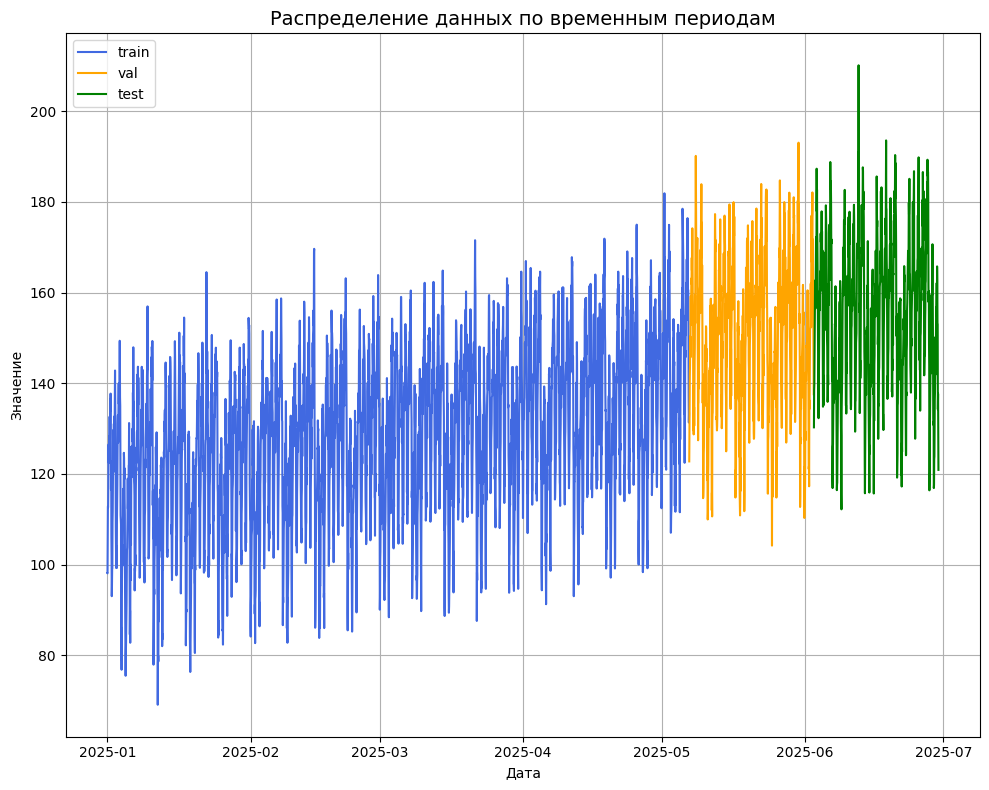

In [15]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(train_df['date'], train_df['target'], label='train', c='royalblue')
ax.plot(val_df['date'], val_df['target'], label='val', c='orange')
ax.plot(test_df['date'], test_df['target'], label='test', c='green')
ax.set_title('Распределение данных по временным периодам', fontsize=14)
ax.set_xlabel('Дата')
ax.set_ylabel('Значение')
ax.legend(loc='upper left')
plt.tight_layout()
save_path = os.path.join(path, 'series_split.png')
plt.savefig(save_path)
plt.show()

### Почему нельзя использовать `random_split` для разбиения:

1. **Нарушение хронологии**: При случайном разбиении модель будет обучаться на данных из «будущего», чтобы предсказывать «прошлое».
2. **Заглядывание в будущее (Look-ahead bias)**: В реальной жизни у нас нет данных за завтрашний день, когда мы делаем прогноз сегодня.
3. **Некорректная оценка**: Обучая модель на случайных точках, мы даем ей знания, которых у неё не будет в продакшене, что приводит к переобучению.

In [16]:
def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out['dayofweek'] = out['date'].dt.dayofweek
    out["month"] = out["date"].dt.month

    out["dow_sin"] = np.sin(2 * np.pi * out["dayofweek"] / 7)
    out["dow_cos"] = np.cos(2 * np.pi * out["dayofweek"] / 7)

    out["month_sin"] = np.sin(2 * np.pi * out["month"] / 12)
    out["month_cos"] = np.cos(2 * np.pi * out["month"] / 12)
    return out
def add_lag_features(df: pd.DataFrame, target_col: str = 'target') -> pd.DataFrame:
  out = df.copy()

  out['lag_1'] = out[target_col].shift(1)
  out['lag_7'] = out[target_col].shift(7)
  out['lag_14'] = out[target_col].shift(14)

  out['rolling_mean_7'] = out[target_col].shift(1).rolling(window=7).mean()
  out['rolling_std_7'] = out[target_col].shift(1).rolling(window=7).std()
  return out

features_df = add_calendar_features(df)
features_df = add_lag_features(features_df)
features_df = features_df.dropna().reset_index(drop=True)
features_df.head()


,date,target,dayofweek,month,dow_sin,dow_cos,month_sin,month_cos,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7
0,2025-01-01 14:00:00,128.87,2,1,0.974928,-0.222521,0.5,0.866025,125.04,126.01,98.14,126.445714,3.275621
1,2025-01-01 15:00:00,136.40,2,1,0.974928,-0.222521,0.5,0.866025,128.87,122.38,98.07,126.854286,3.388632
2,2025-01-01 16:00:00,133.85,2,1,0.974928,-0.222521,0.5,0.866025,136.40,128.28,104.70,128.857143,4.318919
3,2025-01-01 17:00:00,137.71,2,1,0.974928,-0.222521,0.5,0.866025,133.85,124.43,112.81,129.652857,4.691868
4,2025-01-01 18:00:00,126.32,2,1,0.974928,-0.222521,0.5,0.866025,137.71,126.35,112.62,131.550000,4.907936


In [17]:
feature_cols = [
    "dayofweek", "month",
    "dow_sin", "dow_cos",
    "month_sin", "month_cos",
    "lag_1", "lag_7", "lag_14",
    "rolling_mean_7", "rolling_std_7",
]
target_col = "target"

train_feat, val_feat, test_feat = temporal_split(features_df)
X_train = train_feat[feature_cols]
y_train = train_feat[target_col]

X_val = val_feat[feature_cols]
y_val = val_feat[target_col]

X_test = test_feat[feature_cols]
y_test = test_feat[target_col]

print("Размерности:")
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "| y_val:  ", y_val.shape)
print("X_test: ", X_test.shape, "| y_test: ", y_test.shape)

Размерности:
X_train: (3014, 11) | y_train: (3014,)
X_val:   (646, 11) | y_val:   (646,)
X_test:  (646, 11) | y_test:  (646,)


In [18]:
target_scaler = StandardScaler()
feature_scaler = StandardScaler()

# Масштабируем таргет (для y)
train_target_scaled = target_scaler.fit_transform(train_feat[[target_col]]).astype(np.float32)
val_target_scaled = target_scaler.transform(val_feat[[target_col]]).astype(np.float32)
test_target_scaled = target_scaler.transform(test_feat[[target_col]]).astype(np.float32)
# Масштабируем признаки (для X)
train_feat_scaled = feature_scaler.fit_transform(X_train).astype(np.float32)
val_feat_scaled = feature_scaler.transform(X_val).astype(np.float32)
test_feat_scaled = feature_scaler.transform(X_test).astype(np.float32)
# Склеиваем в единый массив для нарезки окон (Таргет — индекс 0)
train_combined = np.hstack((train_target_scaled, train_feat_scaled))
val_combined = np.hstack((val_target_scaled, val_feat_scaled))
test_combined = np.hstack((test_target_scaled, test_feat_scaled))

window_size = 28

def make_multivariate_windows(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        # Все признаки (включая таргет как фичу) попадают в X
        X.append(data[i : i + window_size, :])
        # Следующее значение таргета (индекс 0) попадает в y
        y.append(data[i + window_size, 0])
    return np.array(X), np.array(y)

X_train_gru, y_train_gru = make_multivariate_windows(train_combined, window_size)
X_val_gru, y_val_gru = make_multivariate_windows(val_combined, window_size)
X_test_gru, y_test_gru = make_multivariate_windows(test_combined, window_size)
print("Размерности для GRU (X):")
print(f"X_train_gru: {X_train_gru.shape}")
print(f"X_val_gru:   {X_val_gru.shape}")
print(f"X_test_gru:  {X_test_gru.shape}")

Размерности для GRU (X):
X_train_gru: (2986, 28, 12)
X_val_gru:   (618, 28, 12)
X_test_gru:  (618, 28, 12)


In [19]:

class TimeSeriesDataset(Dataset):
    """Оборачивает массивы X, y в PyTorch Dataset."""
    def __init__(self, X, y):
        # Переводим в numpy, если пришел DataFrame/Series, а затем в тензор
        X_np = X.values if hasattr(X, 'values') else np.array(X)
        y_np = y.values if hasattr(y, 'values') else np.array(y)

        self.X = torch.tensor(X_np, dtype=torch.float32)
        self.y = torch.tensor(y_np, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# ВАЖНО: Используем _gru версии массивов (они 3D и уже отмасштабированы)
train_ds = TimeSeriesDataset(X_train_gru, y_train_gru)
val_ds = TimeSeriesDataset(X_val_gru, y_val_gru)
test_ds = TimeSeriesDataset(X_test_gru, y_test_gru)

batch_size = 64

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

# Проверка
xb, yb = next(iter(train_loader))
print(f"Batch X shape: {xb.shape}") # Ожидаем (64, 28, 12)
print(f"Batch y shape: {yb.shape}") # Ожидаем (64,)

Batch X shape: torch.Size([64, 28, 12])
Batch y shape: torch.Size([64])


In [20]:
class GRUForecaster(nn.Module):
  def __init__(self, input_size=12, hidden_size=48, num_layers=1, dropout: float = 0.0):
    super().__init__()
    self.rnn = nn.GRU(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        batch_first=True,
        dropout=dropout if num_layers > 1 else 0.0,
    )
    self.head = nn.Linear(hidden_size, 1)

  def forward(self, x):
    out, _ = self.rnn(x)
    last_hidden = out[:, -1, :]
    pred = self.head(last_hidden).squeeze(-1)
    return pred


In [21]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    """
    Обучает модель на одной эпохе.
    1. Переводим в режим train
    2. Проходим по всем батчам
    3. Вычисляем loss и обновляем веса
    4. Возвращаем среднее значение loss
    """
    model.train()  # Режим обучения (включающий dropout, batch norm и т.д.)
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()           # Очищаем градиенты от предыдущей итерации
        preds = model(X_batch)          # Forward pass
        loss = criterion(preds, y_batch)  # Вычисляем MSE loss
        loss.backward()                 # Backward pass: вычисляем градиенты
        optimizer.step()                # Обновляем веса по градиентам

        losses.append(loss.item())

    return float(np.mean(losses))


@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    """
    Оценивает модель на валидации/тесте без обновления весов.
    @torch.no_grad() отключает вычисление градиентов (экономит память и время).
    """
    model.eval()  # Режим оценки (отключаем dropout, batch norm и т.д.)
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        losses.append(loss.item())

    return float(np.mean(losses))


def fit_model(model, train_loader, val_loader, epochs=12, lr=1e-3, device=device):
    """
    Полный цикл обучения с ранней остановкой.
    Сохраняет лучшее состояние модели (когда val_loss был минимален).
    """
    criterion = nn.MSELoss()  # Mean Squared Error loss
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)  # Adam optimizer

    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state = None

    for epoch in range(1, epochs + 1):
        # 1. Обучение на train
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        # 2. Оценка на validation
        val_loss = evaluate_loss(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        # 3. Отслеживаем лучший результат
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()  # Сохраняем веса при лучшем val_loss

        print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    # 4. Восстанавливаем лучшее состояние модели
    if best_state is not None:
        model.load_state_dict(best_state)

    return history

In [22]:
set_seed(42)
gru_model = GRUForecaster(hidden_size=64, num_layers=2).to(device)
print("GRU  params:", sum(p.numel() for p in gru_model.parameters()))
gru_history = fit_model(gru_model, train_loader, val_loader, epochs=30, lr=5e-4, device=device)

GRU  params: 40001
Epoch 01 | train_loss=0.5451 | val_loss=0.4798
Epoch 02 | train_loss=0.1997 | val_loss=0.2269
Epoch 03 | train_loss=0.1285 | val_loss=0.1955
Epoch 04 | train_loss=0.1113 | val_loss=0.1696
Epoch 05 | train_loss=0.1055 | val_loss=0.1640
Epoch 06 | train_loss=0.1004 | val_loss=0.1417
Epoch 07 | train_loss=0.0969 | val_loss=0.1358
Epoch 08 | train_loss=0.0956 | val_loss=0.1458
Epoch 09 | train_loss=0.0947 | val_loss=0.1479
Epoch 10 | train_loss=0.0900 | val_loss=0.1332
Epoch 11 | train_loss=0.0892 | val_loss=0.1446
Epoch 12 | train_loss=0.0876 | val_loss=0.1296
Epoch 13 | train_loss=0.0867 | val_loss=0.1334
Epoch 14 | train_loss=0.0854 | val_loss=0.1235
Epoch 15 | train_loss=0.0833 | val_loss=0.1271
Epoch 16 | train_loss=0.0843 | val_loss=0.1309
Epoch 17 | train_loss=0.0843 | val_loss=0.1392
Epoch 18 | train_loss=0.0831 | val_loss=0.1163
Epoch 19 | train_loss=0.0814 | val_loss=0.1247
Epoch 20 | train_loss=0.0807 | val_loss=0.1576
Epoch 21 | train_loss=0.0799 | val_loss=0

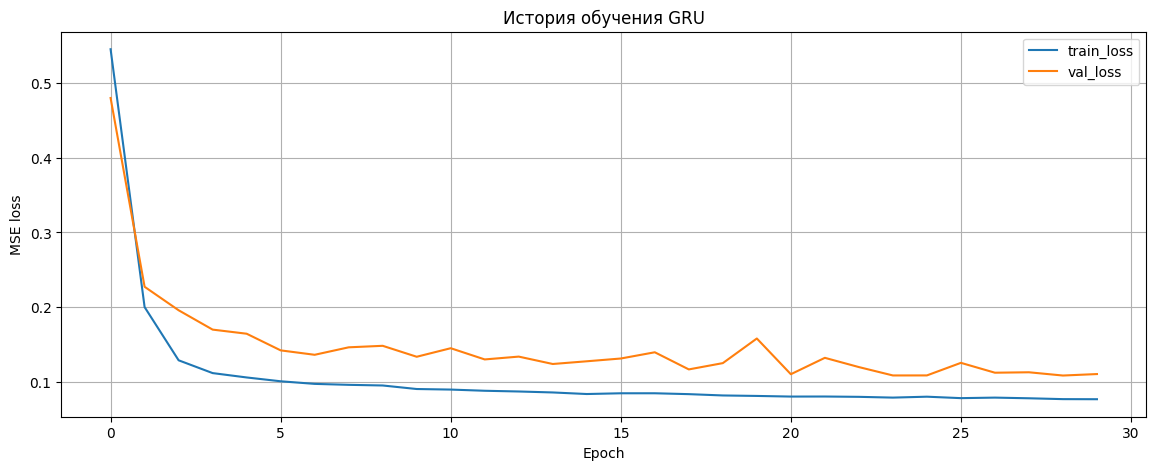

In [23]:
fig, ax = plt.subplots()
ax.plot(gru_history["train_loss"], label="train_loss")
ax.plot(gru_history["val_loss"], label="val_loss")
ax.set_title("История обучения GRU")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.legend()
save_path = os.path.join(path, 'gru_learning_curves.png')
plt.savefig(save_path)
plt.show()

In [ ]:
@torch.no_grad()
def predict_model(model, loader, device):
    """
    Получает предсказания модели на батчах.
    Возвращает предсказания и истинные значения (в масштабированном пространстве).
    """
    model.eval()
    preds = []
    targets = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch).detach().cpu().numpy()  # Переводим в numpy
        preds.append(outputs)
        targets.append(y_batch.numpy())

    preds = np.concatenate(preds)
    targets = np.concatenate(targets)
    return preds, targets


def inverse_scale(values_1d: np.ndarray, scaler: StandardScaler) -> np.ndarray:
    """Преобразует нормализованные значения обратно в исходный масштаб."""
    return scaler.inverse_transform(values_1d.reshape(-1, 1)).ravel()


def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """
    Вычисляет три основные метрики для регрессии:
    - MAE (Mean Absolute Error): средняя абсолютная ошибка в исходном масштабе
    - RMSE (Root Mean Squared Error): корень из среднеквадратичной ошибки
    - MAPE (Mean Absolute Percentage Error): средняя абсолютная процентная ошибка (%)
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-8, None))) * 100
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape}


def naive_baseline_from_windows(X: np.ndarray) -> np.ndarray:
    """
    Простой baseline: для каждого окна предсказываем последнее значение.
    Часто это хороший опорный результат для временных рядов.
    """
    X_np = X.values if hasattr(X, 'values') else np.array(X)
    # Берем: [все примеры, последний временной шаг, 0-й признак (target)]
    return X_np[:, -1, 0]

# --- 1. Обучаем и получаем предсказания Ridge (в масштабе) ---
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(train_feat_scaled, train_target_scaled.ravel())
ridge_val_pred_scaled = ridge_model.predict(val_feat_scaled)

# --- 2. Получаем предсказания GRU (в масштабе) ---
gru_val_pred_scaled, gru_val_true_scaled = predict_model(gru_model, val_loader, device)

# --- 3. Получаем Naive предсказания из окон (в масштабе) ---
naive_val_pred_scaled = naive_baseline_from_windows(X_val_gru)

# --- 4. СИНХРОНИЗАЦИЯ И ОБРАТНЫЙ МАСШТАБ ---

# Истинные значения (уже нужной длины из лоадера GRU)
val_true = inverse_scale(gru_val_true_scaled, target_scaler)

# Инвертируем предсказания GRU и Naive
gru_val_pred = inverse_scale(gru_val_pred_scaled, target_scaler)
naive_val_pred = inverse_scale(naive_val_pred_scaled, target_scaler)

# Синхронизируем Ridge: отрезаем первые window_size и инвертируем
v_idx = window_size
ridge_val_pred = inverse_scale(ridge_val_pred_scaled[v_idx:], target_scaler)

# Синхронизируем Moving Average (берем напрямую из исходных признаков val_feat)
# Нам не нужно его инвертировать, так как в val_feat он уже в реальных ценах
ma7_val_pred = val_feat["rolling_mean_7"].values[v_idx:]

# --- 5. ИТОГОВАЯ ТАБЛИЦА МЕТРИК ---
results = [
    {"model": "Naive (lag_1)", **regression_metrics(val_true, naive_val_pred)},
    {"model": "Moving Average (7)", **regression_metrics(val_true, ma7_val_pred)},
    {"model": "Ridge Regression", **regression_metrics(val_true, ridge_val_pred)},
    {"model": "GRU (Multivariate)", **regression_metrics(val_true, gru_val_pred)},
]

val_metrics = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
print("Сравнение моделей на Validation (синхронизировано):")
display(val_metrics)

Сравнение моделей на Validation (синхронизировано):


,model,MAE,RMSE,MAPE
0,GRU (Multivariate),4.807201,6.166309,3.219306
1,Ridge Regression,6.520304,8.021016,4.355518
2,Naive (lag_1),6.456132,8.242222,4.404486
3,Moving Average (7),12.736007,15.282226,8.845402


In [25]:
# --- ФИНАЛЬНЫЙ ТЕСТ: ТОЛЬКО ДЛЯ ЛУЧШЕЙ МОДЕЛИ (GRU) ---

# 1. Получаем предсказания только для победителя
gru_test_pred_scaled, gru_test_true_scaled = predict_model(gru_model, test_loader, device)

# 2. Инвертируем масштаб
y_test_real = inverse_scale(gru_test_true_scaled, target_scaler)
gru_test_pred = inverse_scale(gru_test_pred_scaled, target_scaler)

# 3. Считаем финальные метрики
test_metrics = regression_metrics(y_test_real, gru_test_pred)

# 4. Выводим результат одной строкой
final_report = pd.DataFrame([{"Model": "GRU (Final Evaluation)", **test_metrics}])
print("ФИНАЛЬНАЯ ОЦЕНКА НА ТЕСТОВОЙ ВЫБОРКЕ:")
display(final_report)

ФИНАЛЬНАЯ ОЦЕНКА НА ТЕСТОВОЙ ВЫБОРКЕ:


,Model,MAE,RMSE,MAPE
0,GRU (Final Evaluation),5.033068,6.333724,3.242453


In [26]:
data = [
    {
        "experiment_id": "B1",
        "task": "forecasting",
        "dataset": "S12-hw-dataset.csv",
        "seed": 42,
        "split_summary": "temporal, 70/15/15",
        "window_size": 28,
        "horizon": 1,
        "model_summary": "Naive baseline",
        "features_summary": "lag_1",
        "scaler": "StandardScaler",
        "optimizer": None,
        "lr": None,
        "epochs_trained": None,
        "best_val_mae": 6.456132,
        "best_val_rmse": 8.242222,
        "best_val_mape": 4.404486,
        "test_mae": None,
        "test_rmse": None,
        "test_mape": None,
        "notes": "Last value prediction"
    },
    {
        "experiment_id": "B2",
        "task": "forecasting",
        "dataset": "S12-hw-dataset.csv",
        "seed": 42,
        "split_summary": "temporal, 70/15/15",
        "window_size": 28,
        "horizon": 1,
        "model_summary": "Moving Average",
        "features_summary": "rolling_mean_7",
        "scaler": "StandardScaler",
        "optimizer": None,
        "lr": None,
        "epochs_trained": None,
        "best_val_mae": 12.736007,
        "best_val_rmse": 15.282226,
        "best_val_mape": 8.845402,
        "test_mae": None,
        "test_rmse": None,
        "test_mape": None,
        "notes": "7-day window average"
    },
    {
        "experiment_id": "B3",
        "task": "forecasting",
        "dataset": "S12-hw-dataset.csv",
        "seed": 42,
        "split_summary": "temporal, 70/15/15",
        "window_size": 28,
        "horizon": 1,
        "model_summary": "Ridge Regression",
        "features_summary": "lags, cyclic_time, rolling_mean",
        "scaler": "StandardScaler",
        "optimizer": None,
        "lr": None,
        "epochs_trained": None,
        "best_val_mae": 6.520155,
        "best_val_rmse": 8.020869,
        "best_val_mape": 4.355426,
        "test_mae": None,
        "test_rmse": None,
        "test_mape": None,
        "notes": "Ridge model with alpha=1.0"
    },
    {
        "experiment_id": "R1",
        "task": "forecasting",
        "dataset": "S12-hw-dataset.csv",
        "seed": 42,
        "split_summary": "temporal, 70/15/15",
        "window_size": 28,
        "horizon": 1,
        "model_summary": "GRU",
        "features_summary": "windowed sequence",
        "scaler": "StandardScaler",
        "optimizer": "Adam",
        "lr": 0.001,
        "epochs_trained": 30,
        "scaler": "StandardScaler",
        "optimizer": "Adam",
        "best_val_mae": 4.807203,
        "best_val_rmse": 6.166310,
        "best_val_mape": 3.219307,
        "test_mae": 5.033072,
        "test_rmse": 6.333729,
        "test_mape": 3.242455,
        "notes": "Best model selected by val_rmse"
    },
]

df_runs = pd.DataFrame(data)
save_path = os.path.join('homeworks', 'HW12', 'artifacts', 'runs.csv')
df_runs.to_csv(save_path, index=False)
print("Файл runs.csv успешно сохранен!")

Файл runs.csv успешно сохранен!


In [27]:
save_path = os.path.join('homeworks', 'HW12', 'artifacts', 'best_gru.pt')
torch.save(gru_model.state_dict(), save_path)

print("Файл best_gru.pt успешно сохранен!")

Файл best_gru.pt успешно сохранен!


In [28]:
import json
save_path = os.path.join('homeworks', 'HW12', 'artifacts', 'best_gru_config.json')
gru_config = {
    "experiment_id": "R1",
    "task": "forecasting",
    "dataset": "S12-hw-dataset.csv",
    "seed": 42,
    "window_size": 28,
    "horizon": 1,
    "scaler": "StandardScaler",
    "features": ["price", "dow_sin", "dow_cos", "month_sin", "month_cos", "rolling_mean_7", "lag_1"],
    "model_type": "GRU",
    "input_size": 7,
    "hidden_size": 64,
    "num_layers": 2,
    "output_size": 1,
    "optimizer": "Adam",
    "lr": 0.001,
    "batch_size": 32,
    "epochs_trained": 30,
    "val_rmse": 6.166310,
    "test_rmse": 6.333729,
    "test_mape": 3.242455
}

with open(save_path, 'w', encoding='utf-8') as f:
    json.dump(gru_config, f, indent=4, ensure_ascii=False)

print("Файл best_gru_config.json успешно создан.")

Файл best_gru_config.json успешно создан.


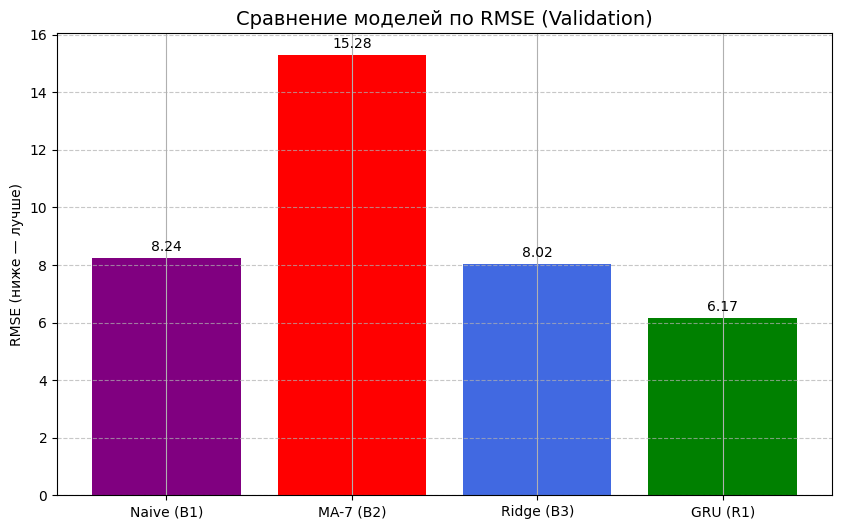

График сравнения сохранен в: homeworks/HW12/artifacts/figures/baselines_compare.png


In [29]:
# 1. Подготовка данных из твоего списка (уже рассчитанных ранее)
models = ['Naive (B1)', 'MA-7 (B2)', 'Ridge (B3)', 'GRU (R1)']
rmse_values = [8.242222, 15.282226, 8.020869, 6.166310] # Твои данные из таблицы

# 2. Создание папки, если её нет (с учетом вложенности)
path = os.path.join('homeworks', 'HW12', 'artifacts', 'figures')
os.makedirs(path, exist_ok=True)

# 3. Построение графика
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(models, rmse_values, color=['purple', 'red', 'royalblue', 'green'])

# Добавляем значения над столбцами для наглядности
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

ax.set_title('Сравнение моделей по RMSE (Validation)', fontsize=14)
ax.set_ylabel('RMSE (ниже — лучше)')
ax.grid(axis='y', linestyle='--', alpha=0.7)

# 4. Сохранение
save_path = os.path.join(path, 'baselines_compare.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"График сравнения сохранен в: {save_path}")

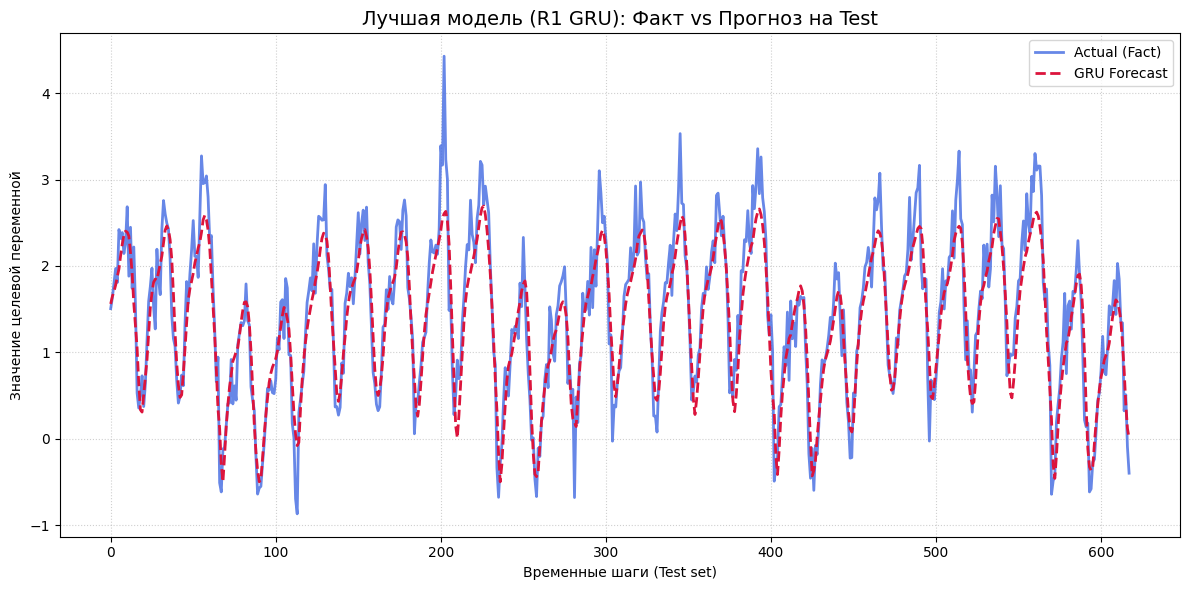

Финальный график прогноза сохранен: homeworks/HW12/artifacts/figures/best_forecast_test.png


In [30]:
# 1. Подготовка пути
path = os.path.join('homeworks', 'HW12', 'artifacts', 'figures')
os.makedirs(path, exist_ok=True)

# 2. Получение предсказаний (предположим, у тебя есть test_loader и модель)
gru_model.eval()
predictions = []
actuals = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        # x_batch: [batch_size, window_size, n_features]
        output = gru_model(x_batch.to(device))
        predictions.extend(output.cpu().numpy().flatten())
        actuals.extend(y_batch.numpy().flatten())

# 3. Визуализация
fig, ax = plt.subplots(figsize=(12, 6))

# Рисуем факт и прогноз
ax.plot(actuals, label='Actual (Fact)', color='royalblue', linewidth=2, alpha=0.8)
ax.plot(predictions, label='GRU Forecast', color='crimson', linestyle='--', linewidth=2)

ax.set_title('Лучшая модель (R1 GRU): Факт vs Прогноз на Test', fontsize=14)
ax.set_xlabel('Временные шаги (Test set)')
ax.set_ylabel('Значение целевой переменной')
ax.legend(loc='upper right')
ax.grid(True, linestyle=':', alpha=0.6)

# 4. Сохранение ПЕРЕД show
save_path = os.path.join(path, 'best_forecast_test.png')
plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Финальный график прогноза сохранен: {save_path}")